In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

### Cargar datos

In [24]:
ruta_energia = "energiasedif1(11 pisosycomunes).csv"
ruta_agua = "VOLUMENAGUACALIENTECONSUMIDA.csv"

df_energia = pd.read_csv(ruta_energia)
df_agua = pd.read_csv(ruta_agua)

In [25]:
df_agua.tail()

,Unnamed: 0,volumenBA,volumenBB,volumen1C,volumen2A,volumen2B,volumen3A,volumen3B,volumen4A,volumen4B,volumen5A,volumen5B
9523,2026-02-01 19:00:00,2836.0,9151.00,10757.0,7790.23,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9524,2026-02-01 20:00:00,2836.0,9151.00,10757.0,7791.00,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9525,2026-02-01 21:00:00,2836.0,9151.00,10757.0,7792.22,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9526,2026-02-01 22:00:00,2836.0,9153.95,10757.0,7793.48,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9527,2026-02-01 23:00:00,2836.0,9154.00,10757.0,7794.00,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0


In [26]:
# renombrar la primera columna como 'fecha'
df_energia = df_energia.rename(columns={df_energia.columns[0]: "fecha"})
df_agua = df_agua.rename(columns={df_agua.columns[0]: "fecha"})

# convertir fecha
df_energia["fecha"] = pd.to_datetime(df_energia["fecha"], errors="coerce")
df_agua["fecha"] = pd.to_datetime(df_agua["fecha"], errors="coerce")

# eliminar filas iniciales vacías
cols_energia_sin_fecha = df_energia.columns[1:]
cols_agua_sin_fecha = df_agua.columns[1:]

mask_energia = df_energia[cols_energia_sin_fecha].notna().any(axis=1)
mask_agua = df_agua[cols_agua_sin_fecha].notna().any(axis=1)

primera_fila_energia = mask_energia.idxmax()
primera_fila_agua = mask_agua.idxmax()

df_energia = df_energia.loc[primera_fila_energia:].reset_index(drop=True)
df_agua = df_agua.loc[primera_fila_agua:].reset_index(drop=True)

In [27]:
cols_pisos_energia = [c for c in df_energia.columns if c.startswith("energia") and c != "energia"]
cols_pisos_agua = [c for c in df_agua.columns if c.startswith("volumen")]

print("Columnas energía por piso:")
print(cols_pisos_energia)

print("\nColumnas agua por piso:")
print(cols_pisos_agua)

Columnas energía por piso:
['energiaBA', 'energiaBB', 'energia1C', 'energia2A', 'energia2B', 'energia3A', 'energia3B', 'energia4A', 'energia4B', 'energia5A', 'energia5B']

Columnas agua por piso:
['volumenBA', 'volumenBB', 'volumen1C', 'volumen2A', 'volumen2B', 'volumen3A', 'volumen3B', 'volumen4A', 'volumen4B', 'volumen5A', 'volumen5B']


### Crear columnas no acumulativas

In [28]:
# como son variables acumulativas, restar para encontrar aumento 
for col in cols_pisos_energia + ["energia"]:
    df_energia[col] = pd.to_numeric(df_energia[col], errors="coerce")

for col in cols_pisos_agua:
    df_agua[col] = pd.to_numeric(df_agua[col], errors="coerce")

df_energia_diff = df_energia.copy()
df_agua_diff = df_agua.copy()

for col in cols_pisos_energia + ["energia"]:
    df_energia_diff[col] = df_energia_diff[col].diff()

for col in cols_pisos_agua:
    df_agua_diff[col] = df_agua_diff[col].diff()

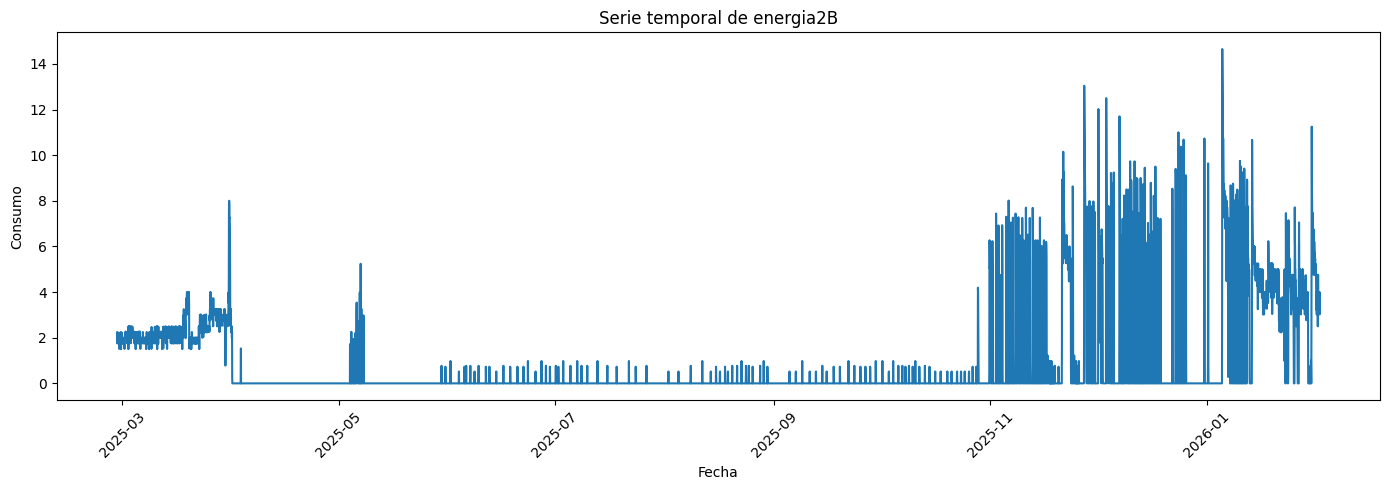

In [29]:
plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff["energiaBB"])
plt.title("Serie temporal de energia2B")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

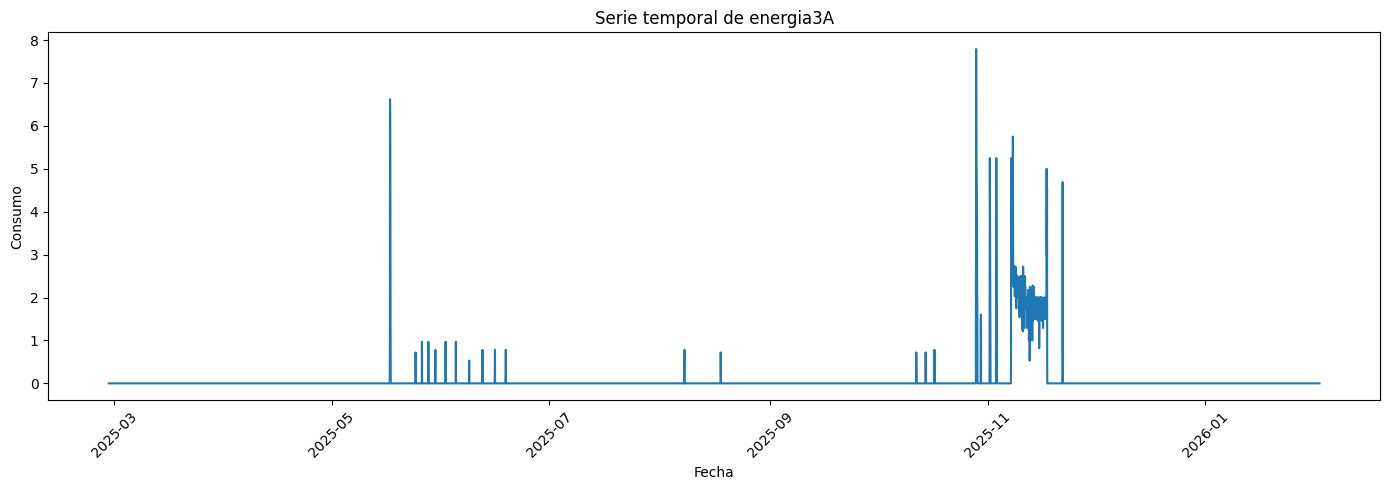

In [30]:
plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff["energia3A"])
plt.title("Serie temporal de energia3A")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

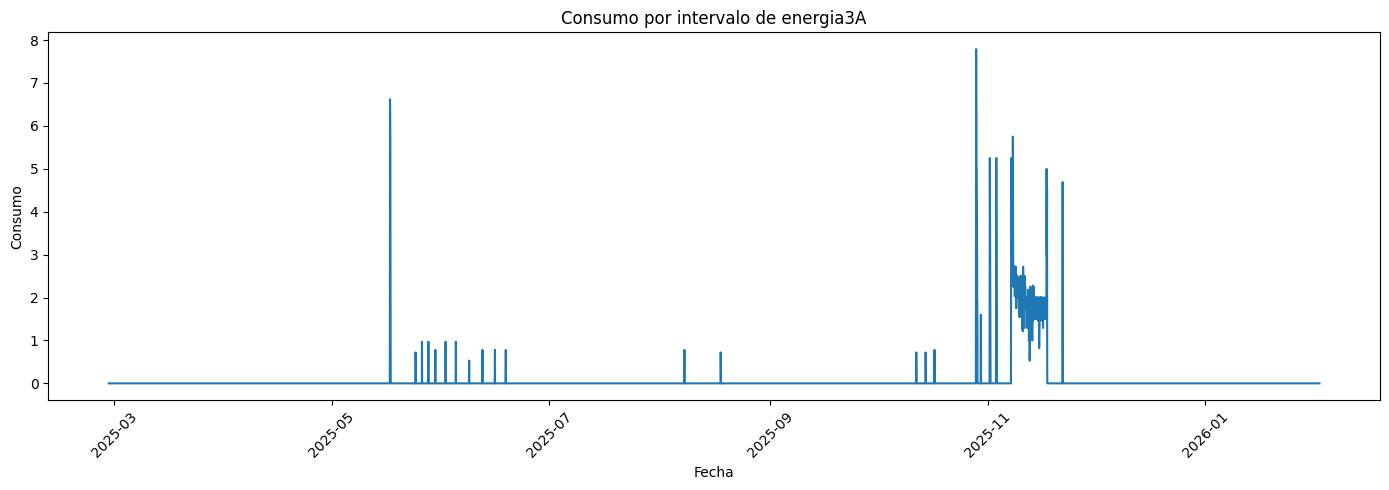

In [31]:
col_ejemplo = cols_pisos_energia[5]

plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff[col_ejemplo])
plt.title(f"Consumo por intervalo de {col_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
def plot_month_apartment(
    df_energia_diff,
    df_agua_diff,
    data_type="energia", #'energia' or 'agua'
    apartment="energia3A",
    year=2025,
    month=11,
    daily=False,
    kind="line"
):
    """
    Plot energy or water consumption for one apartment in a chosen month and year.

    Parameters
    ----------
    df_energia_diff : pandas.DataFrame
        DataFrame with non-cumulative energy data. Must contain a 'fecha' column.
    df_agua_diff : pandas.DataFrame
        DataFrame with non-cumulative water data. Must contain a 'fecha' column.
    data_type : str
        'energia' or 'agua'
    apartment : str
        Example: 'energia1C' or 'volumen1C'
    year : int
        Year to plot
    month : int
        Month to plot (1 to 12)
    daily : bool
        If True, aggregates by day inside the selected month
    kind : str
        'line' or 'bar'
    """

    # Validate inputs
    if data_type not in ["energia", "agua"]:
        raise ValueError("data_type must be 'energia' or 'agua'")

    if not 1 <= month <= 12:
        raise ValueError("month must be between 1 and 12")

    if kind not in ["line", "bar"]:
        raise ValueError("kind must be 'line' or 'bar'")

    # Select dataframe
    if data_type == "energia":
        df = df_energia_diff.copy()
        ylabel = "Energy consumption"
    else:
        df = df_agua_diff.copy()
        ylabel = "Water consumption"

    # Check fecha column
    if "fecha" not in df.columns:
        raise ValueError("The selected dataframe must contain a 'fecha' column")

    # Convert fecha to datetime
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # Check apartment column
    if apartment not in df.columns:
        raise ValueError(f"'{apartment}' is not a column in the selected dataframe")

    # Keep only selected month and year
    df_plot = df[
        (df["fecha"].dt.year == year) &
        (df["fecha"].dt.month == month)
    ].copy()

    if df_plot.empty:
        print(f"No data found for {apartment} in {year}-{month:02d}")
        return

    # Keep only the columns we need
    df_plot = df_plot[["fecha", apartment]].dropna()

    if df_plot.empty:
        print(f"No non-null data found for {apartment} in {year}-{month:02d}")
        return

    # Aggregate daily if requested
    if daily:
        df_plot = df_plot.set_index("fecha").resample("D").sum().reset_index()
        title_period = f"{year}-{month:02d} (daily)"
    else:
        title_period = f"{year}-{month:02d}"

    # Plot
    plt.figure(figsize=(14, 5))

    if kind == "line":
        plt.plot(df_plot["fecha"], df_plot[apartment], marker="o")
    elif kind == "bar":
        plt.bar(df_plot["fecha"].astype(str), df_plot[apartment])

    plt.title(f"{data_type.capitalize()} consumption - {apartment} - {title_period}")
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

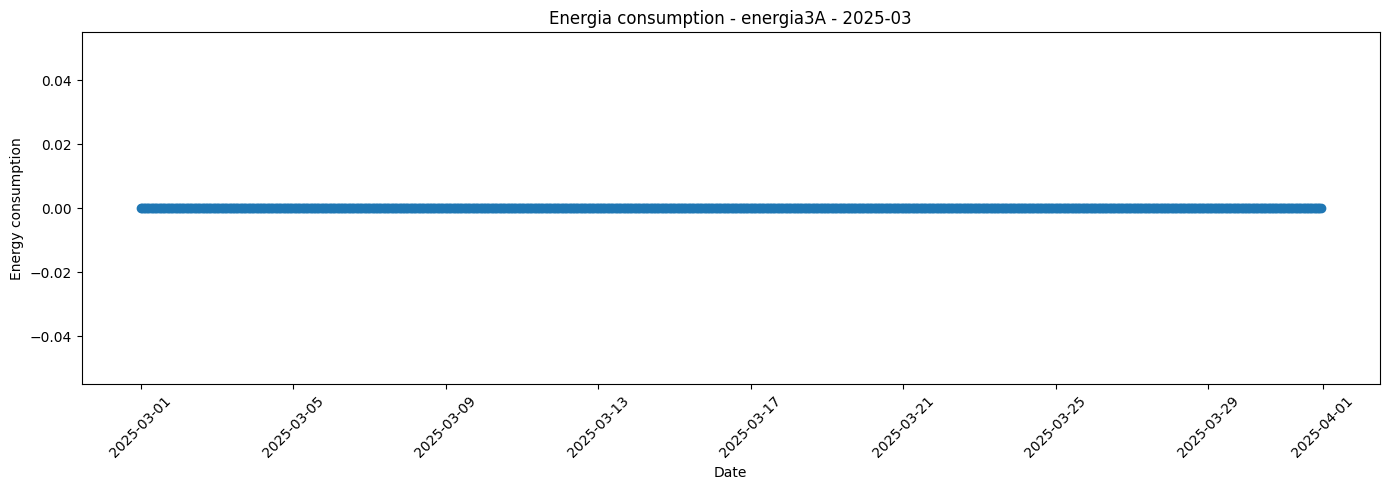

In [33]:
plot_month_apartment(df_energia_diff, df_agua_diff,month=3)

### Crear modelo XGB

Shape final del dataset de entrenamiento: (87780, 14)
Train: (61457, 14)
Valid: (13167, 14)
Test: (13156, 14)
MAE: 0.4882698689208714
RMSE: 1.106669648634126


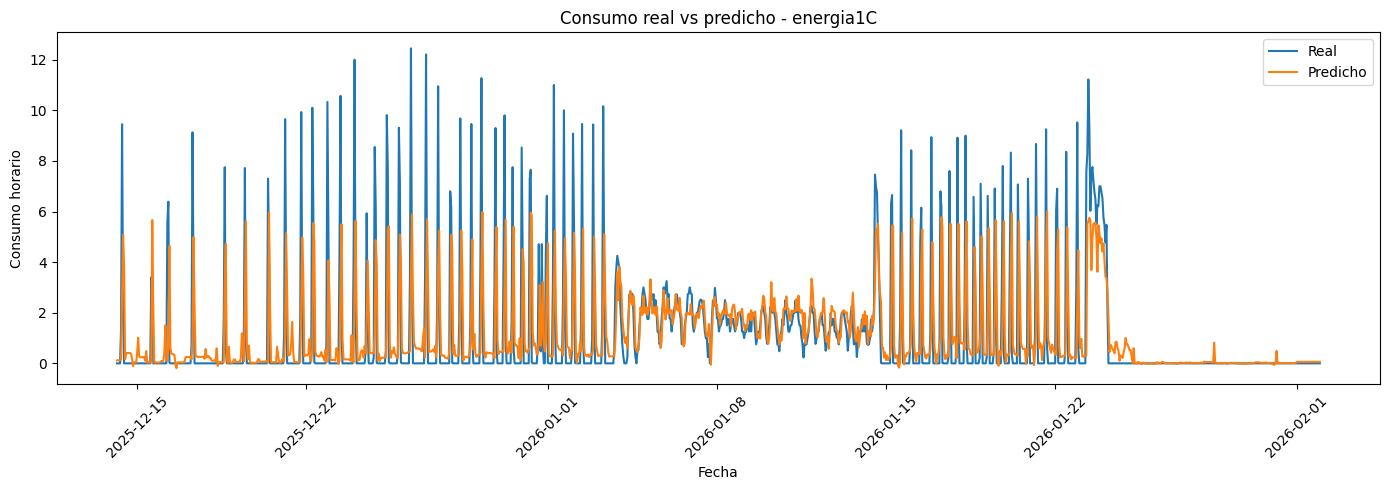

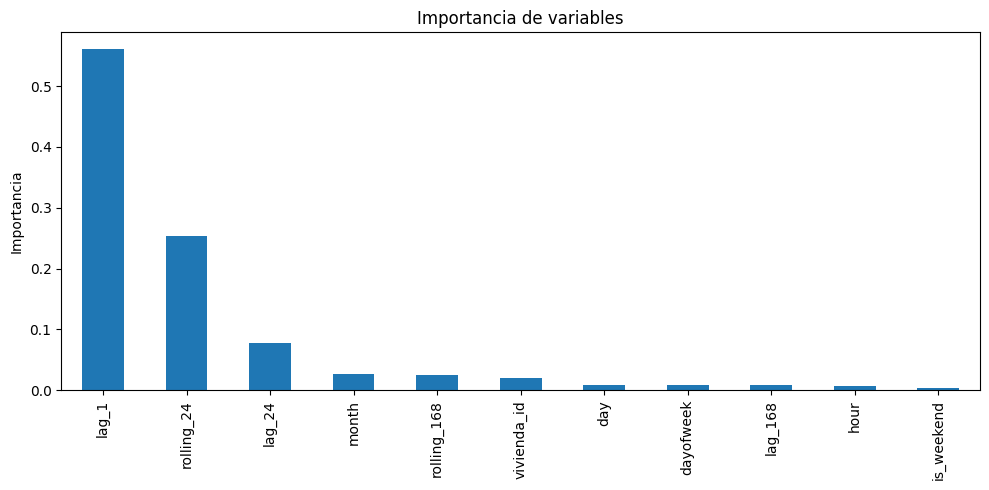

In [39]:
# Nos quedamos solo con energía, no agua
df_train = df_energia_diff.copy()

# Si quieres, evita negativos raros tras diff
for col in cols_pisos_energia:
    df_train[col] = df_train[col].clip(lower=0)

# %%
# Pasar a formato largo: una fila = una hora de una vivienda
df_long = df_train.melt(
    id_vars="fecha",
    value_vars=cols_pisos_energia,
    var_name="vivienda",
    value_name="consumo"
)

df_long = df_long.dropna().copy()
df_long = df_long.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

df_long.head()

# %%
# Variables temporales
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

# %%
# Lags por vivienda
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# %%
# Medias móviles por vivienda
df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)


# Codificar vivienda como número
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# Eliminar filas con nulos generados por lags/rolling
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
df_model.head()

# División temporal: 70% train, 15% valid, 15% test
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)

features = [
    "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_24",
    "rolling_168"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

# %%
model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# %%
# Predicción en test
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# %%
# Guardar resultados
results = test[["fecha", "vivienda", "consumo"]].copy()
results["pred"] = y_pred

results.head()

# %%
# Visualizar una vivienda concreta
vivienda_ejemplo = "energia1C"   # cambia esto por la que quieras

r = results[results["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %%
# Importancia de variables
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

In [ ]:
for vivienda in results["vivienda"].unique():
    r = results[results["vivienda"] == vivienda].copy()

    plt.figure(figsize=(14,5))
    plt.plot(r["fecha"], r["consumo"], label="Real")
    plt.plot(r["fecha"], r["pred"], label="Predicho")
    plt.title(f"Consumo real vs predicho - {vivienda}")
    plt.xlabel("Fecha")
    plt.ylabel("Consumo horario")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Añadir más lags

Shape final del dataset de entrenamiento: (87780, 21)
Train: (61457, 21)
Valid: (13167, 21)
Test: (13156, 21)
MAE: 0.438835248243885
RMSE: 1.0754974830884354


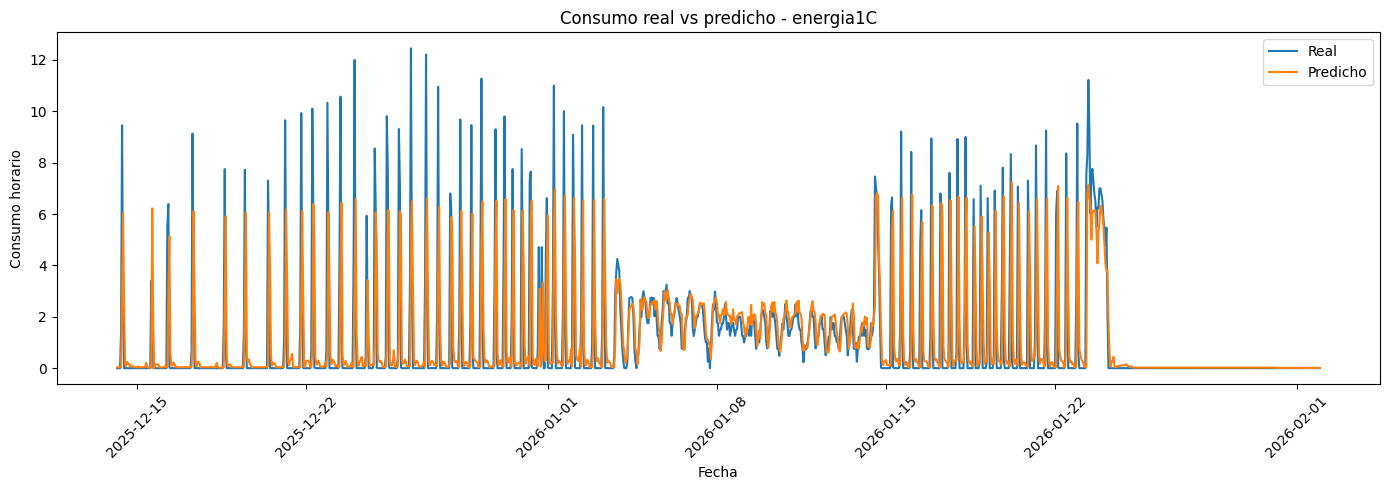

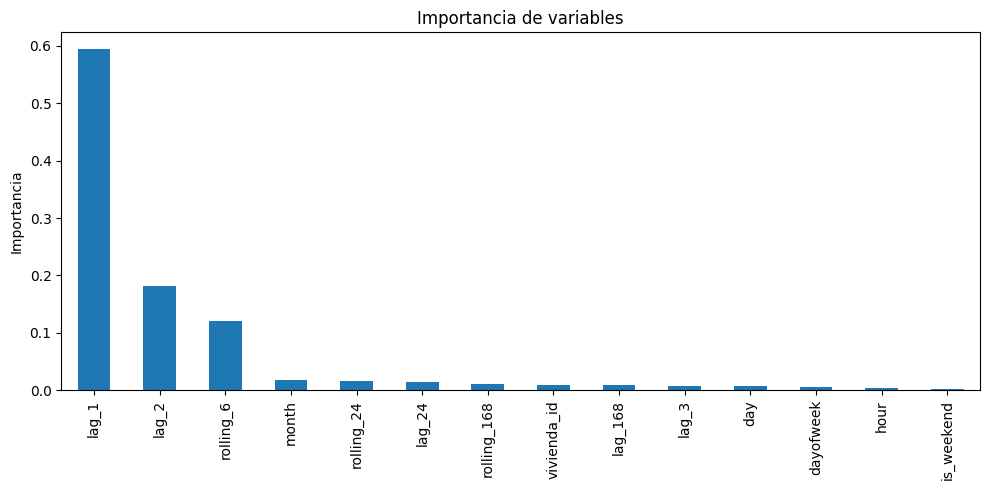

In [51]:
# Variables temporales
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

# Lags por vivienda
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_2"] = df_long.groupby("vivienda")["consumo"].shift(2)
df_long["lag_3"] = df_long.groupby("vivienda")["consumo"].shift(3)
df_long["lag_6"] = df_long.groupby("vivienda")["consumo"].shift(6)
df_long["lag_12"] = df_long.groupby("vivienda")["consumo"].shift(12)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_48"] = df_long.groupby("vivienda")["consumo"].shift(48)
df_long["lag_72"] = df_long.groupby("vivienda")["consumo"].shift(72)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# Medias móviles por vivienda
df_long["rolling_6"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(6).mean())
)

df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)

# Codificar vivienda como número
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# Eliminar filas con nulos generados por lags/rolling
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
df_model.head()

# División temporal: 70% train, 15% valid, 15% test
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)

features = [
    "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    # "lag_6",
    # "lag_12",
    "lag_24",
    # "lag_48",
    # "lag_72",
    "lag_168",
    "rolling_6",
    "rolling_24",
    "rolling_168"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]



model2 = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model2.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)


# Predicción en test
y_pred = model2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# %%
# Guardar resultados
results2 = test[["fecha", "vivienda", "consumo"]].copy()
results2["pred"] = y_pred

results2.head()

# %%
# Visualizar una vivienda concreta
vivienda_ejemplo = "energia1C"   # cambia esto por la que quieras

r = results2[results2["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %%
# Importancia de variables
importancias = pd.Series(model2.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

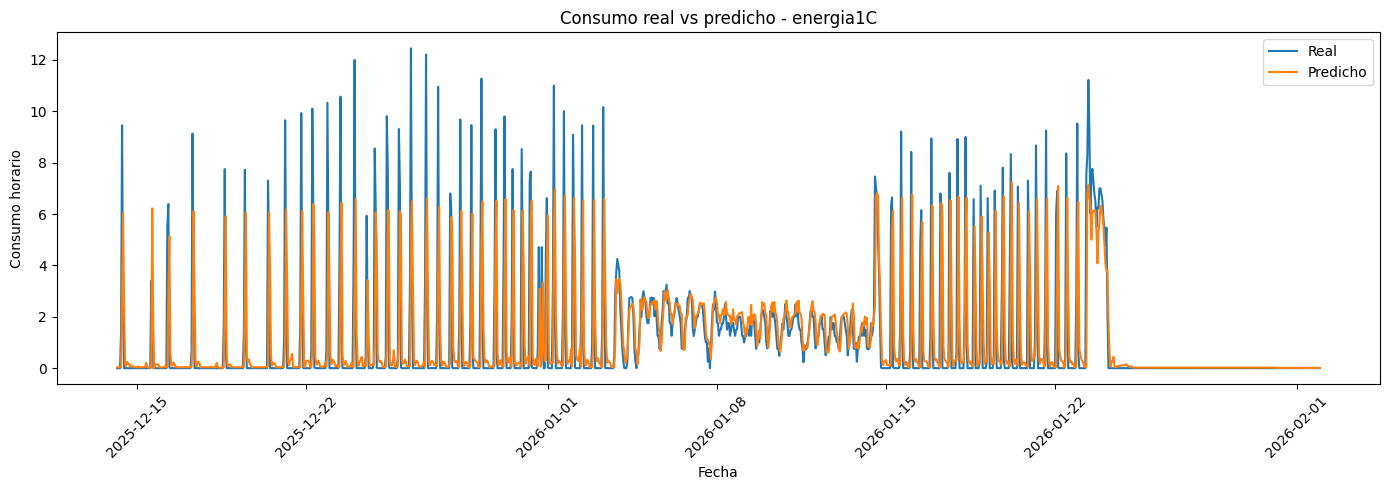

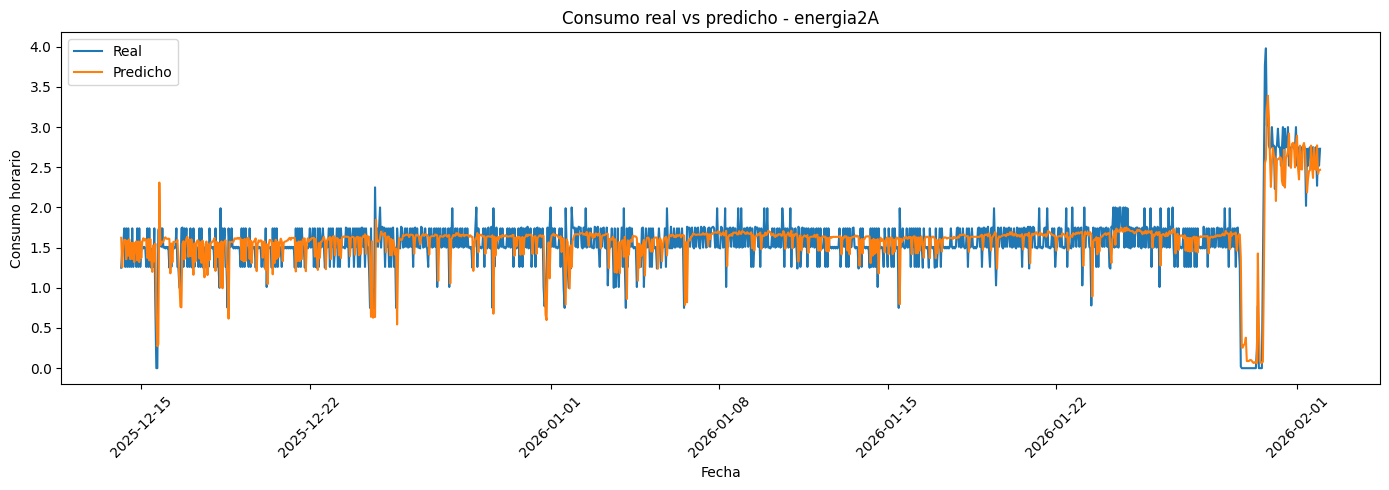

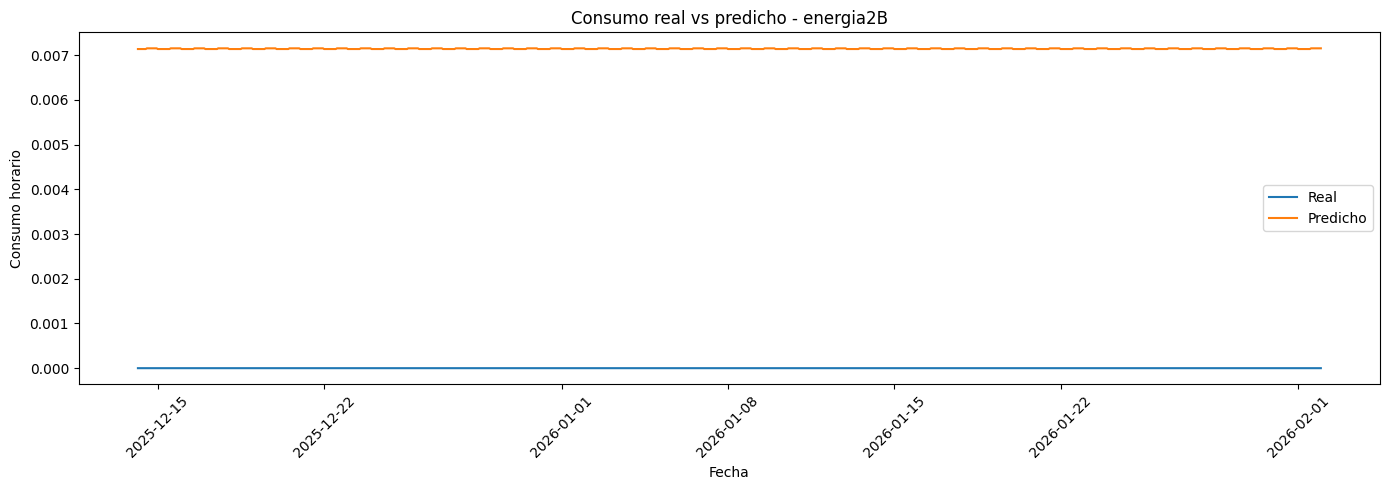

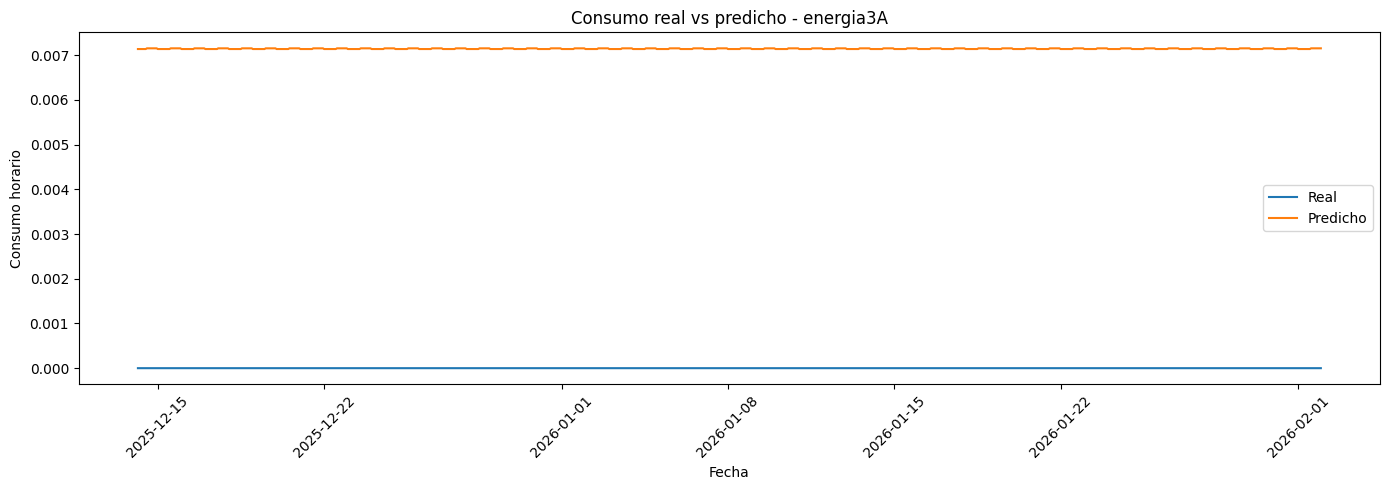

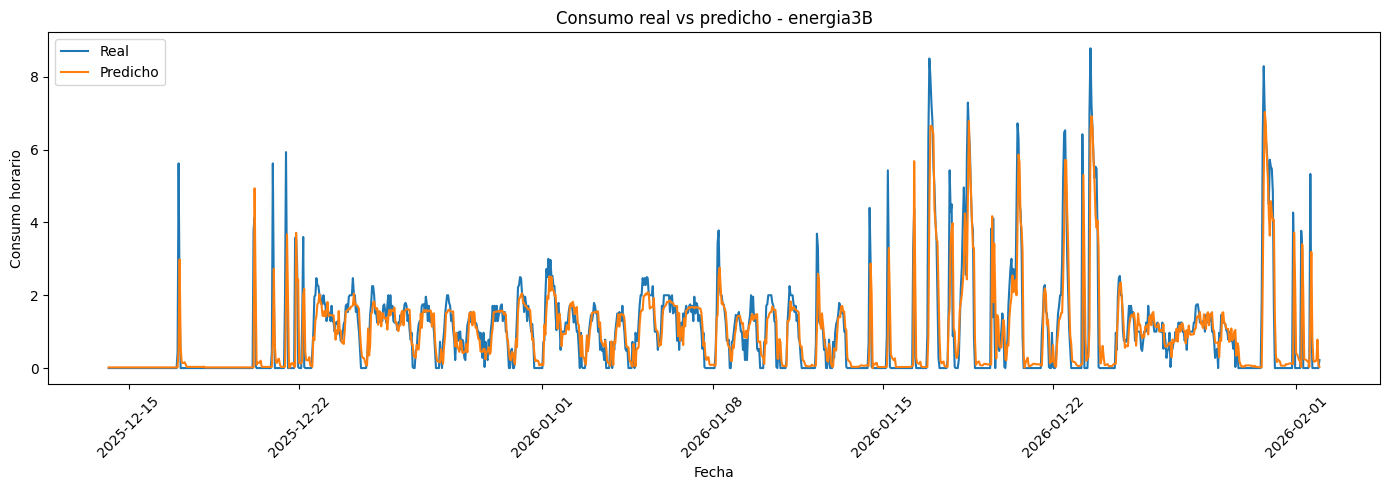

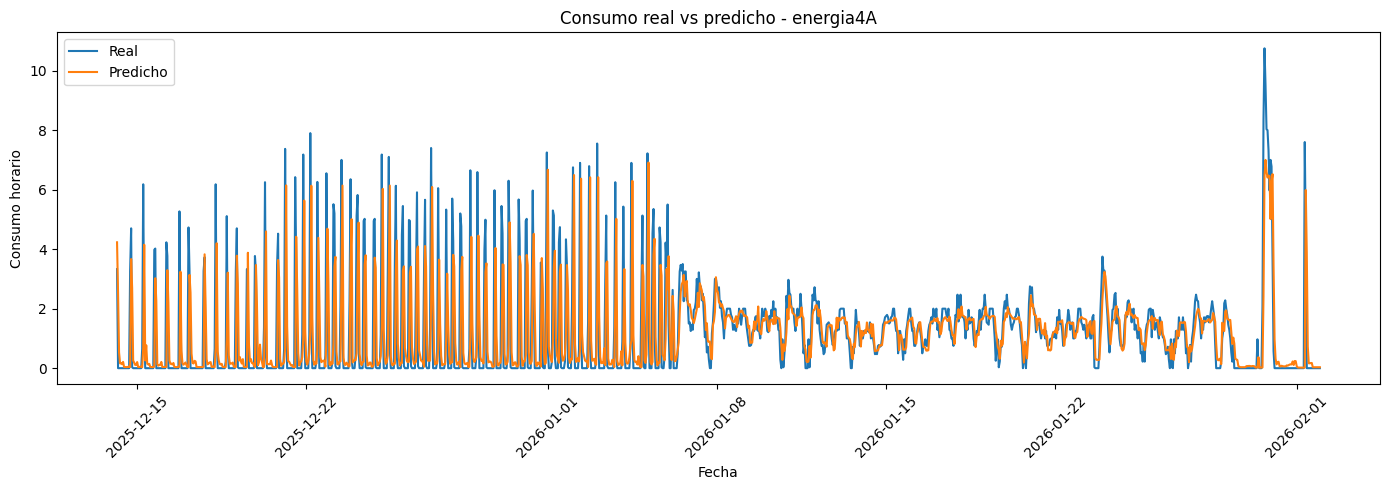

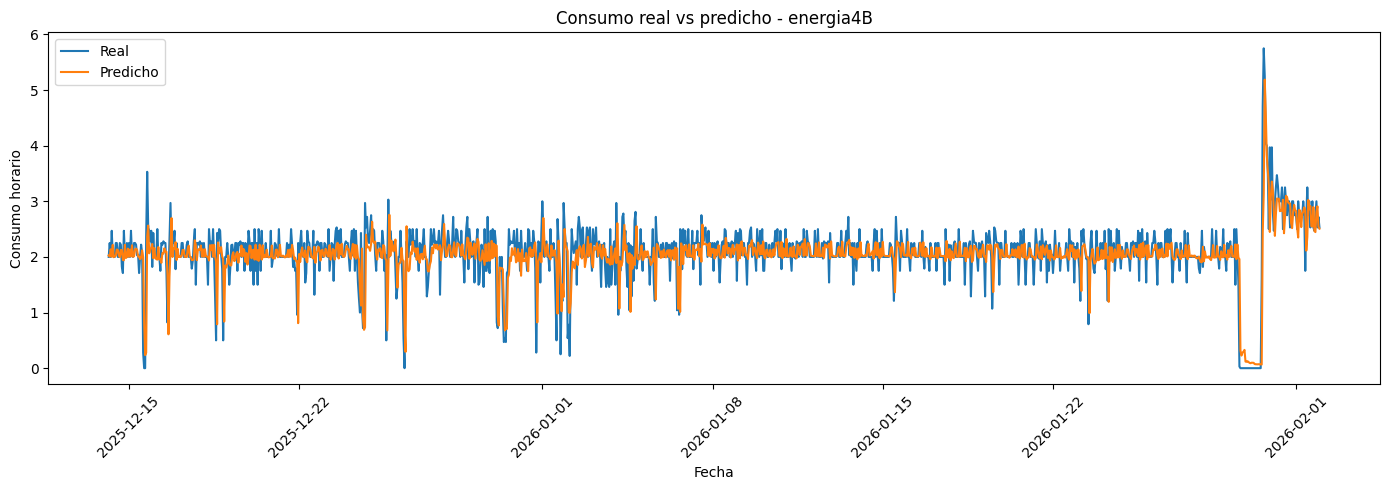

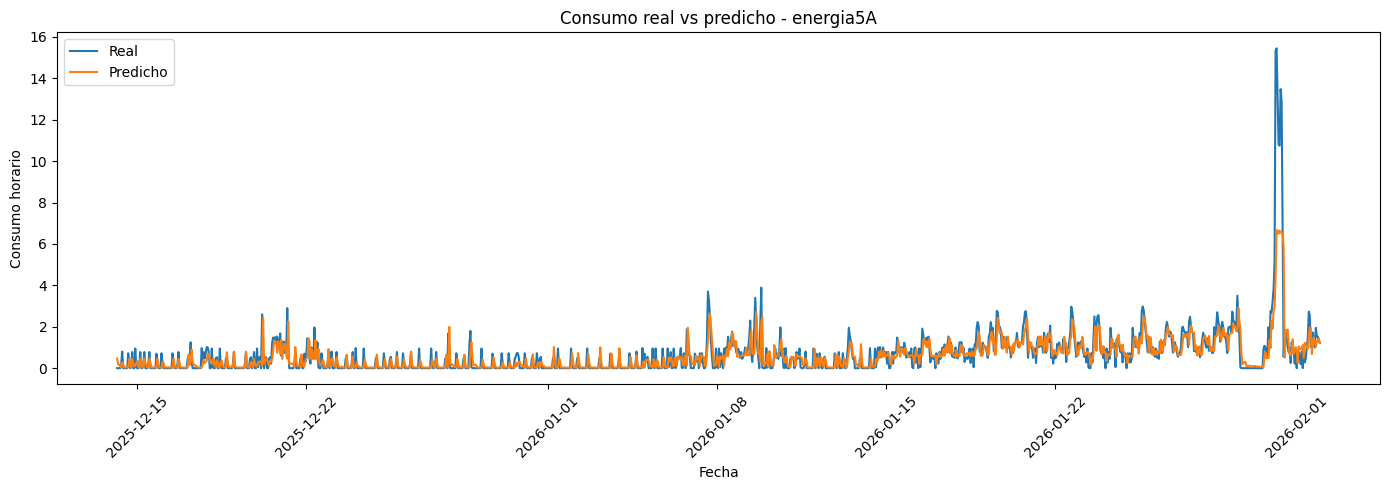

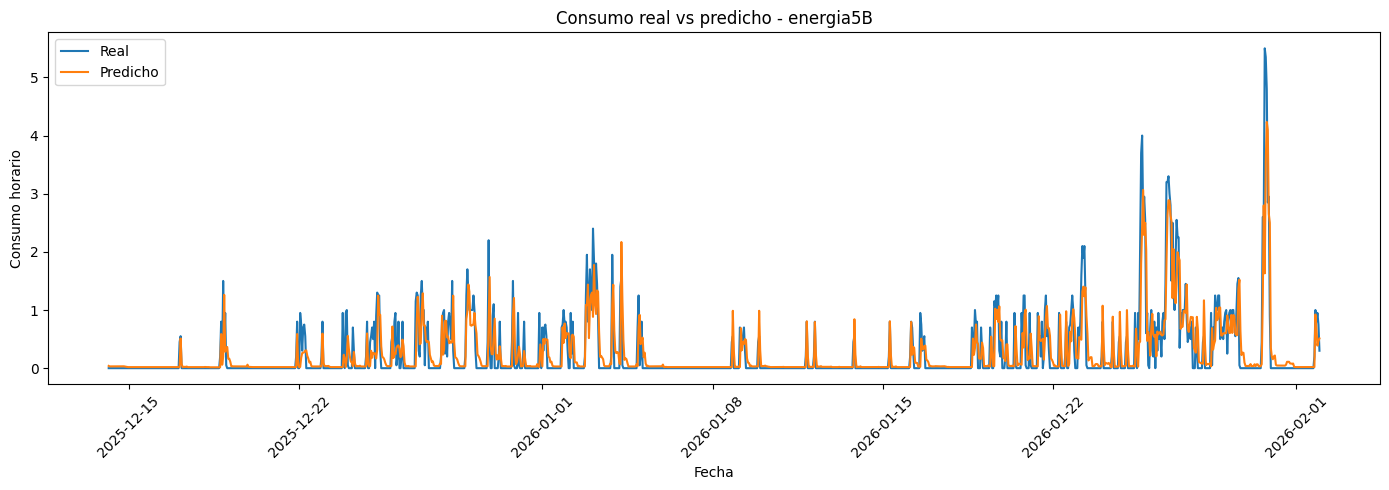

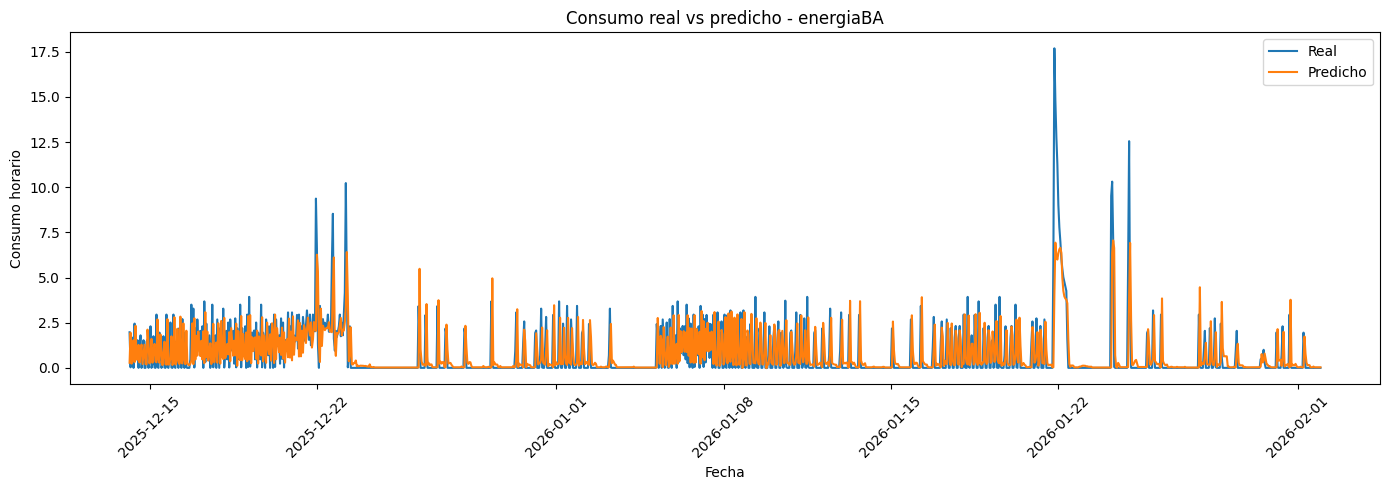

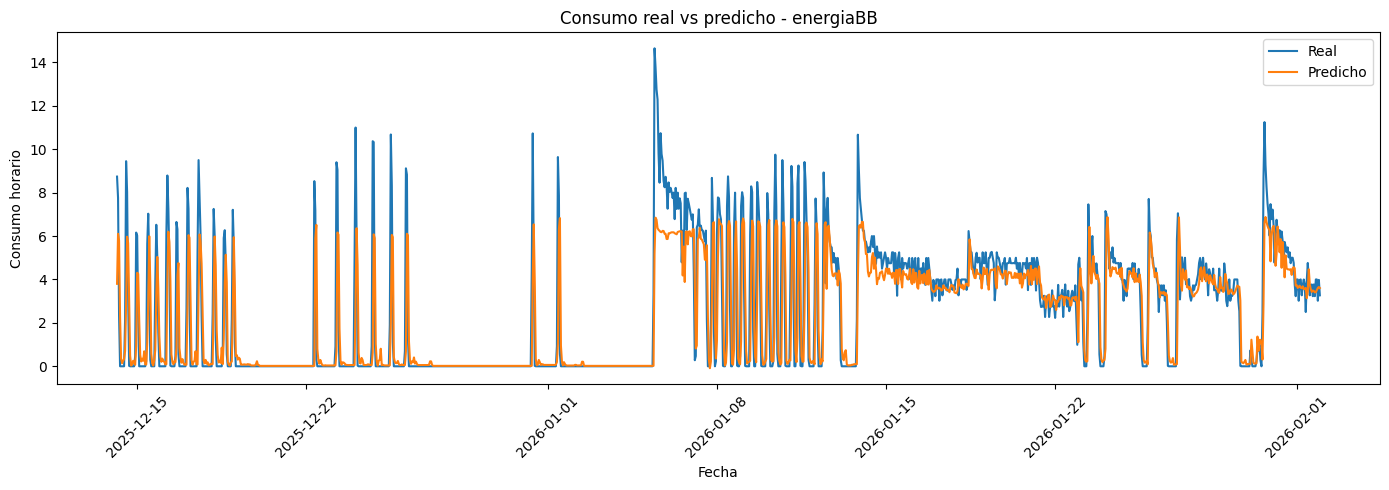

In [52]:
for vivienda in results2["vivienda"].unique():
    r = results2[results2["vivienda"] == vivienda].copy()

    plt.figure(figsize=(14,5))
    plt.plot(r["fecha"], r["consumo"], label="Real")
    plt.plot(r["fecha"], r["pred"], label="Predicho")
    plt.title(f"Consumo real vs predicho - {vivienda}")
    plt.xlabel("Fecha")
    plt.ylabel("Consumo horario")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Con chronos preentrenado 

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import torch
# import numpy as np
# from chronos import Chronos2Pipeline
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # =========================================================
# # 1. PREPARAR DATOS DE TODAS LAS VIVIENDAS
# # =========================================================
# df = df_energia_diff[["fecha"] + cols_pisos_energia].copy()
# df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# for col in cols_pisos_energia:
#     df[col] = pd.to_numeric(df[col], errors="coerce").clip(lower=0)

# df = df.dropna(subset=["fecha"]).sort_values("fecha").reset_index(drop=True)

# # Formato largo
# df_long = df.melt(
#     id_vars="fecha",
#     value_vars=cols_pisos_energia,
#     var_name="id",
#     value_name="target"
# ).dropna().copy()

# df_long = df_long.sort_values(["id", "fecha"]).reset_index(drop=True)

# # =========================================================
# # 2. SPLIT TRAIN / TEST POR VIVIENDA
# # =========================================================
# horizon = 24 * 7   # prueba primero 7 días; luego si quieres subes a 30 días

# train_parts = []
# test_parts = []

# for vivienda, g in df_long.groupby("id"):
#     g = g.sort_values("fecha").reset_index(drop=True)

#     # Saltar viviendas demasiado cortas
#     if len(g) <= horizon:
#         continue

#     train_g = g.iloc[:-horizon].copy()
#     test_g = g.iloc[-horizon:].copy()

#     train_parts.append(train_g)
#     test_parts.append(test_g)

# context_df = pd.concat(train_parts, ignore_index=True)
# test_df = pd.concat(test_parts, ignore_index=True)

# # Renombrar columnas como espera Chronos-2
# context_df = context_df.rename(columns={"fecha": "timestamp"})
# test_df = test_df.rename(columns={"fecha": "timestamp"})

# print("Context shape:", context_df.shape)
# print("Test shape:", test_df.shape)
# print("Series usadas:", context_df["id"].nunique())

# # =========================================================
# # 3. CARGAR CHRONOS-2
# # =========================================================
# pipeline = Chronos2Pipeline.from_pretrained(
#     "amazon/chronos-2",
#     device_map="auto",
#     torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
# )

# # =========================================================
# # 4. PREDECIR TODAS LAS SERIES A LA VEZ
# # =========================================================
# pred_df = pipeline.predict_df(
#     context_df,
#     prediction_length=horizon,
#     quantile_levels=[0.5],
#     id_column="id",
#     timestamp_column="timestamp",
#     target="target",
# )

# print(pred_df.columns)

# # Coger la predicción mediana
# if "prediction" in pred_df.columns:
#     pred_col = "prediction"
# elif "0.5" in pred_df.columns:
#     pred_col = "0.5"
# else:
#     pred_col = pred_df.select_dtypes(include=[np.number]).columns[-1]

# pred_df = pred_df[["id", "timestamp", pred_col]].rename(columns={pred_col: "pred"})

# # =========================================================
# # 5. UNIR REAL VS PREDICHO
# # =========================================================
# results = test_df.merge(pred_df, on=["id", "timestamp"], how="inner")

# print(results.head())

# # =========================================================
# # 6. MÉTRICAS GLOBALES
# # =========================================================
# mae = mean_absolute_error(results["target"], results["pred"])
# rmse = np.sqrt(mean_squared_error(results["target"], results["pred"]))

# print("Chronos-2 global MAE:", mae)
# print("Chronos-2 global RMSE:", rmse)

# # =========================================================
# # 7. MÉTRICAS POR VIVIENDA
# # =========================================================
# metricas_por_vivienda = (
#     results.groupby("id")
#     .apply(lambda g: pd.Series({
#         "MAE": mean_absolute_error(g["target"], g["pred"]),
#         "RMSE": np.sqrt(mean_squared_error(g["target"], g["pred"]))
#     }))
#     .sort_values("MAE")
# )

# print(metricas_por_vivienda)

# # =========================================================
# # 8. GRÁFICAS POR VIVIENDA
# # =========================================================
# for vivienda in results["id"].unique():
#     r = results[results["id"] == vivienda].copy()

#     plt.figure(figsize=(14,5))
#     plt.plot(r["timestamp"], r["target"], label="Real")
#     plt.plot(r["timestamp"], r["pred"], label="Chronos-2")
#     plt.title(f"Chronos-2 vs Real - {vivienda}")
#     plt.xlabel("Fecha")
#     plt.ylabel("Consumo")
#     plt.legend()
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

### Añadir temperatura como dato 

Shape final del dataset de entrenamiento: (87780, 21)
Train: (61457, 21)
Valid: (13167, 21)
Test: (13156, 21)
MAE: 0.4695657559432708
RMSE: 1.0779772211284444
                   fecha   vivienda  consumo      pred
6952 2025-12-14 04:00:00  energia1C     0.00  0.046574
6953 2025-12-14 05:00:00  energia1C     0.00  0.046574
6954 2025-12-14 06:00:00  energia1C     0.00  0.046574
6955 2025-12-14 07:00:00  energia1C     0.00  0.046574
6956 2025-12-14 08:00:00  energia1C     1.42  0.046574


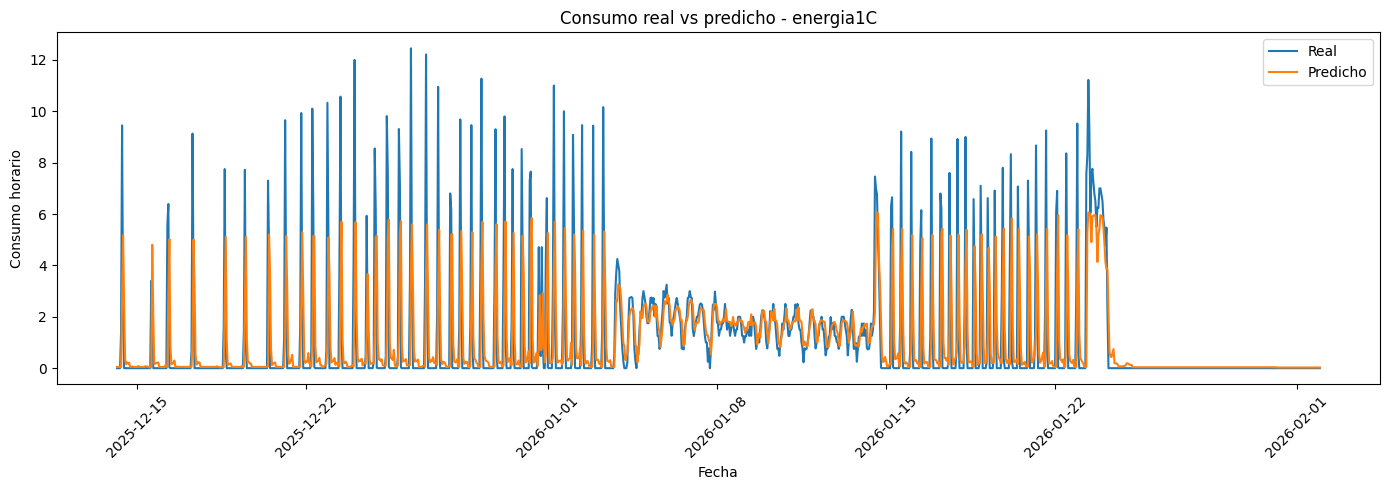

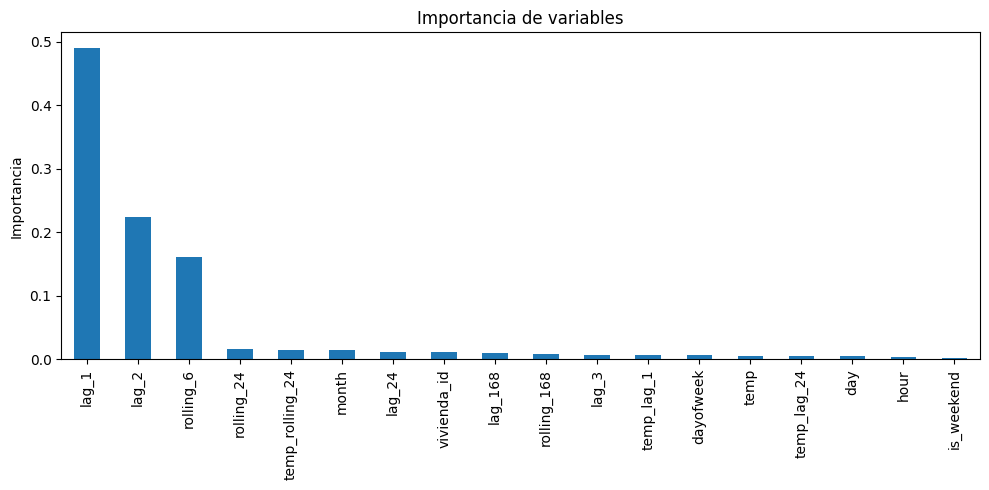

                MAE      RMSE
vivienda                     
energia2B  0.024635  0.024635
energia3A  0.024635  0.024635
energia2A  0.201528  0.270842
energia5B  0.213538  0.378024
energia4B  0.329217  0.445602
energia5A  0.406307  0.792821
energia3B  0.417070  0.798029
energia4A  0.804486  1.474727
energiaBA  0.866204  1.430463
energia1C  0.901054  1.933895
energiaBB  0.976548  1.771988


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. PREPARAR BASE DE ENERGÍA
# =========================================================
# Nos quedamos solo con energía, no agua
df_train = df_energia_diff.copy()

# Evitar negativos raros tras diff
for col in cols_pisos_energia:
    df_train[col] = df_train[col].clip(lower=0)

# Pasar a formato largo: una fila = una hora de una vivienda
df_long = df_train.melt(
    id_vars="fecha",
    value_vars=cols_pisos_energia,
    var_name="vivienda",
    value_name="consumo"
)

df_long = df_long.dropna().copy()
df_long = df_long.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# =========================================================
# 2. DESCARGAR TEMPERATURA HISTÓRICA
# =========================================================
start_date = df_long["fecha"].min().strftime("%Y-%m-%d")
end_date = df_long["fecha"].max().strftime("%Y-%m-%d")

# Cambia estas coordenadas si quieres usar la ubicación exacta del edificio
latitude = 40.4168
longitude = -3.7038

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m",
    "timezone": "Europe/Madrid"
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
weather_json = response.json()

df_temp = pd.DataFrame({
    "fecha": pd.to_datetime(weather_json["hourly"]["time"]),
    "temp": weather_json["hourly"]["temperature_2m"]
})

# =========================================================
# 3. UNIR TEMPERATURA
# =========================================================
df_long = df_long.merge(df_temp, on="fecha", how="left")

# =========================================================
# 4. VARIABLES TEMPORALES
# =========================================================
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

# =========================================================
# 5. LAGS DE CONSUMO POR VIVIENDA
# =========================================================
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_2"] = df_long.groupby("vivienda")["consumo"].shift(2)
df_long["lag_3"] = df_long.groupby("vivienda")["consumo"].shift(3)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# =========================================================
# 6. ROLLING DE CONSUMO POR VIVIENDA
# =========================================================
df_long["rolling_6"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(6).mean())
)

df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)

# =========================================================
# 7. FEATURES DE TEMPERATURA
# =========================================================
df_long["temp_lag_1"] = df_long.groupby("vivienda")["temp"].shift(1)
df_long["temp_lag_24"] = df_long.groupby("vivienda")["temp"].shift(24)

df_long["temp_rolling_24"] = (
    df_long.groupby("vivienda")["temp"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

# =========================================================
# 8. CODIFICAR VIVIENDA
# =========================================================
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# =========================================================
# 9. ELIMINAR NULOS
# =========================================================
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
# print(df_model.head())

# =========================================================
# 10. DIVISIÓN TEMPORAL
# =========================================================
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)

# =========================================================
# 11. FEATURES Y TARGET
# =========================================================
features = [
    "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_168",
    "rolling_6",
    "rolling_24",
    "rolling_168",
    "temp",
    "temp_lag_1",
    "temp_lag_24",
    "temp_rolling_24"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

# =========================================================
# 12. ENTRENAR MODELO
# =========================================================
model_temp = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model_temp.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# =========================================================
# 13. PREDICCIÓN
# =========================================================
y_pred = model_temp.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# =========================================================
# 14. GUARDAR RESULTADOS
# =========================================================
results_temp = test[["fecha", "vivienda", "consumo"]].copy()
results_temp["pred"] = y_pred

print(results_temp.head())

# =========================================================
# 15. VISUALIZAR UNA VIVIENDA
# =========================================================
vivienda_ejemplo = "energia1C"

r = results_temp[results_temp["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14, 5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 16. IMPORTANCIA DE VARIABLES
# =========================================================
importancias = pd.Series(model_temp.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

# =========================================================
# 17. MÉTRICAS POR VIVIENDA
# =========================================================
metricas_por_vivienda = (
    results_temp.groupby("vivienda")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["consumo"], g["pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["consumo"], g["pred"]))
    }))
    .sort_values("MAE")
)

print(metricas_por_vivienda)

In [58]:
# Predicción en test
y_pred = model_temp.predict(X_test)

# Métricas globales
mae_total = mean_absolute_error(y_test, y_pred)
rmse_total = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE total:", mae_total)
print("RMSE total:", rmse_total)

MAE total: 0.4695657559432708
RMSE total: 1.0779772211284444


### BiLSTM

Train: (62744, 3)
Valid: (13442, 3)
Test: (13442, 3)
X_train: (60896, 168) y_train: (60896,)
X_valid: (11594, 168) y_valid: (11594,)
X_test : (11594, 168) y_test : (11594,)
Epoch 1/10 - train_loss: 0.0968 - valid_loss: 1.5939
Epoch 2/10 - train_loss: 0.0785 - valid_loss: 1.6128
Epoch 3/10 - train_loss: 0.0756 - valid_loss: 1.5312
Epoch 4/10 - train_loss: 0.0735 - valid_loss: 1.5204
Epoch 5/10 - train_loss: 0.0721 - valid_loss: 1.4876
Epoch 6/10 - train_loss: 0.0704 - valid_loss: 1.5015
Epoch 7/10 - train_loss: 0.0688 - valid_loss: 1.4568
Epoch 8/10 - train_loss: 0.0654 - valid_loss: 1.3957
Epoch 9/10 - train_loss: 0.0645 - valid_loss: 1.3660
Epoch 10/10 - train_loss: 0.0635 - valid_loss: 1.3605
BiLSTM MAE: 0.4419243633747101
BiLSTM RMSE: 1.1032011681215106
                fecha   vivienda  consumo      pred
0 2025-12-20 02:00:00  energia1C      0.0  0.023605
1 2025-12-20 03:00:00  energia1C      0.0  0.016920
2 2025-12-20 04:00:00  energia1C      0.0  0.011632
3 2025-12-20 05:00:00  en

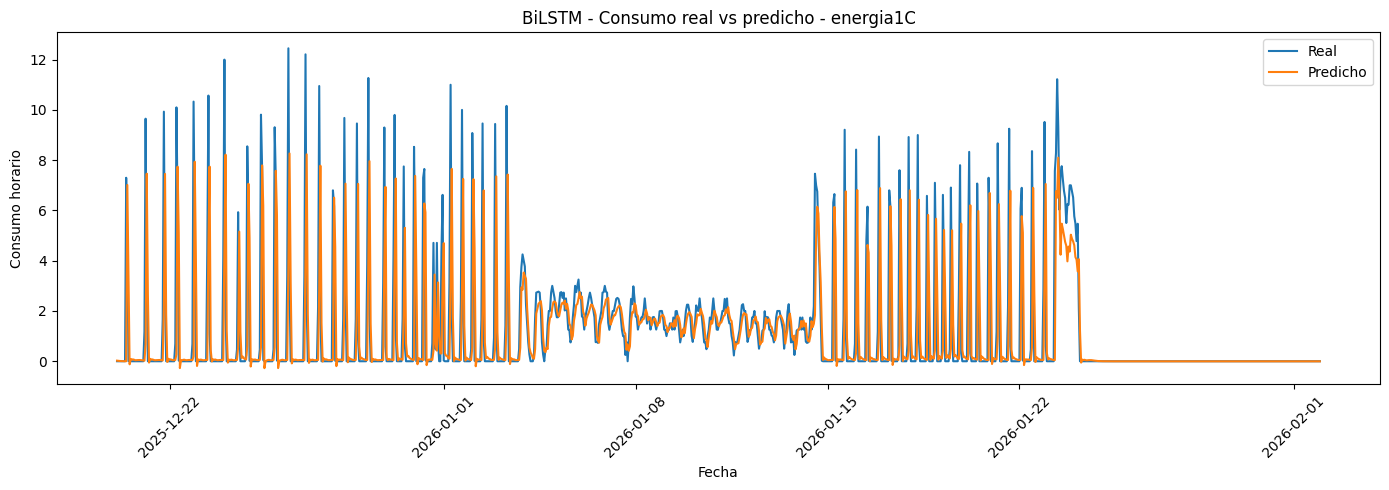

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# =========================================================
# 1. PARTIR DE df_long YA CREADO
# Debe tener al menos:
# fecha, vivienda, consumo
# =========================================================

df_bilstm = df_long[["fecha", "vivienda", "consumo"]].copy()
df_bilstm = df_bilstm.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# =========================================================
# 2. SPLIT TEMPORAL GLOBAL
# =========================================================
fechas_ordenadas = np.array(sorted(df_bilstm["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train_df = df_bilstm[df_bilstm["fecha"] <= train_end].copy()
valid_df = df_bilstm[(df_bilstm["fecha"] > train_end) & (df_bilstm["fecha"] <= valid_end)].copy()
test_df  = df_bilstm[df_bilstm["fecha"] > valid_end].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

# =========================================================
# 3. ESCALAR SOLO CON TRAIN
# =========================================================
scaler = StandardScaler()
scaler.fit(train_df[["consumo"]])

train_df["consumo_scaled"] = scaler.transform(train_df[["consumo"]])
valid_df["consumo_scaled"] = scaler.transform(valid_df[["consumo"]])
test_df["consumo_scaled"]  = scaler.transform(test_df[["consumo"]])

# =========================================================
# 4. CREAR SECUENCIAS POR VIVIENDA
# =========================================================
SEQ_LEN = 24 * 7  # última semana para predecir la siguiente hora

def make_sequences(df_part, seq_len=SEQ_LEN):
    X, y, fechas, viviendas = [], [], [], []

    for vivienda, g in df_part.groupby("vivienda"):
        g = g.sort_values("fecha").reset_index(drop=True)
        values = g["consumo_scaled"].values
        raw_values = g["consumo"].values
        fechas_g = g["fecha"].values

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            X.append(values[i-seq_len:i])
            y.append(values[i])  # target escalado
            fechas.append(fechas_g[i])
            viviendas.append(vivienda)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    fechas = np.array(fechas)
    viviendas = np.array(viviendas)

    return X, y, fechas, viviendas

X_train, y_train, fechas_train, viv_train = make_sequences(train_df)
X_valid, y_valid, fechas_valid, viv_valid = make_sequences(valid_df)
X_test,  y_test,  fechas_test,  viv_test  = make_sequences(test_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# =========================================================
# 5. DATASET / DATALOADER
# =========================================================
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SeqDataset(X_train, y_train)
valid_ds = SeqDataset(X_valid, y_valid)
test_ds  = SeqDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# =========================================================
# 6. MODELO BiLSTM
# =========================================================
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # última salida temporal
        out = self.fc(out)
        return out.squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bilstm = BiLSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_bilstm.parameters(), lr=0.001)

# =========================================================
# 7. ENTRENAMIENTO
# =========================================================
EPOCHS = 10
best_valid_loss = float("inf")
best_state = None

for epoch in range(EPOCHS):
    model_bilstm.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model_bilstm(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model_bilstm.eval()
    valid_losses = []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_bilstm(xb)
            loss = criterion(pred, yb)
            valid_losses.append(loss.item())

    mean_train = np.mean(train_losses)
    mean_valid = np.mean(valid_losses)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {mean_train:.4f} - valid_loss: {mean_valid:.4f}")

    if mean_valid < best_valid_loss:
        best_valid_loss = mean_valid
        best_state = model_bilstm.state_dict()

# cargar mejor modelo
model_bilstm.load_state_dict(best_state)

# =========================================================
# 8. EVALUACIÓN EN TEST
# =========================================================
model_bilstm.eval()
preds_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model_bilstm(xb).cpu().numpy()
        preds_scaled.extend(pred)

preds_scaled = np.array(preds_scaled)

# desescalar
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
preds_real  = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

mae_bilstm = mean_absolute_error(y_test_real, preds_real)
rmse_bilstm = np.sqrt(mean_squared_error(y_test_real, preds_real))

print("BiLSTM MAE:", mae_bilstm)
print("BiLSTM RMSE:", rmse_bilstm)

# =========================================================
# 9. RESULTADOS
# =========================================================
results_bilstm = pd.DataFrame({
    "fecha": fechas_test,
    "vivienda": viv_test,
    "consumo": y_test_real,
    "pred": preds_real
})

print(results_bilstm.head())

# =========================================================
# 10. MÉTRICAS POR VIVIENDA
# =========================================================
metricas_por_vivienda_bilstm = (
    results_bilstm.groupby("vivienda")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["consumo"], g["pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["consumo"], g["pred"]))
    }))
    .sort_values("MAE")
)

print(metricas_por_vivienda_bilstm)

# =========================================================
# 11. GRÁFICA DE UNA VIVIENDA
# =========================================================
vivienda_ejemplo = "energia1C"

r = results_bilstm[results_bilstm["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"BiLSTM - Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()